In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array


In [3]:
data = pd.read_csv(r'D:\weq-preview\madatory task 1\train.csv')

In [4]:
data = data.drop(columns=['posting_id','title','image_phash'])

In [5]:
data

,image,label_group
0,0000a68812bc7e98c42888dfb1c07da0.jpg,249114794
1,00039780dfc94d01db8676fe789ecd05.jpg,2937985045
2,000a190fdd715a2a36faed16e2c65df7.jpg,2395904891
3,00117e4fc239b1b641ff08340b429633.jpg,4093212188
4,00136d1cf4edede0203f32f05f660588.jpg,3648931069
...,...,...
34245,fff1c07ceefc2c970a7964cfb81981c5.jpg,3776555725
34246,fff401691371bdcb382a0d9075dfea6a.jpg,2736479533
34247,fff421b78fa7284284724baf249f522e.jpg,4101248785
34248,fff51b87916dbfb6d0f8faa01bee67b8.jpg,1663538013


In [6]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

In [7]:
em_model = ResNet50(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)

In [8]:
img = load_img(r'D:\weq-preview\madatory task 1\train_images\0000a68812bc7e98c42888dfb1c07da0.jpg')
img = img_to_array(img)
img = np.expand_dims(img,axis=0)
embedding = em_model.predict(img,verbose=0)
embedding

array([[1.8270245 , 1.3601173 , 0.3502852 , ..., 0.18832138, 0.2729646 ,
        0.29900014]], dtype=float32)

In [9]:
def get_image(img_path):
    img = load_img(img_path,target_size=(224,224))
    img = img_to_array(img)
    img = np.expand_dims(img,axis=0)
    embedding = em_model.predict(img,verbose=0)
    return embedding[0]

In [10]:
type(embedding)

numpy.ndarray

In [11]:
image_paths = [
    fr"D:\weq-preview\madatory task 1\train_images\{x}"
    for x in data["image"]
]

In [12]:
def load_and_preprocess(path):

    img = tf.io.read_file(path)

    img = tf.image.decode_jpeg(
        img,
        channels=3
    )

    img = tf.image.resize(
        img,
        (224, 224)
    )

    img = preprocess_input(img)

    return img

In [13]:
dataset = tf.data.Dataset.from_tensor_slices(
    image_paths
)

dataset = dataset.map(
    load_and_preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)

dataset = dataset.batch(64)
dataset = dataset.prefetch(tf.data.AUTOTUNE)

In [14]:
dataset

<_PrefetchDataset element_spec=TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None)>

In [15]:
embeddings = em_model.predict(dataset)

536/536 ━━━━━━━━━━━━━━━━━━━━ 1009s 2s/step


In [16]:
import numpy as np

emb1 = embeddings[0]
emb2 = embeddings[1]

score = np.dot(emb1, emb2) / (
    np.linalg.norm(emb1) * np.linalg.norm(emb2)
)

print(score)

if score >= 0.9:
    print("Same product")
else:
    print("Different product")

0.4183171
Different product


In [17]:
len(data['label_group'])

34250

In [18]:
for i in range(4,len(data['label_group'])):
    for j in range(i+1,len(data['label_group'])):
        if data['label_group'][i] == data['label_group'][j]:
            emb1 = embeddings[i]
            emb2 = embeddings[j]
            print(i,j)
            break
    break

4 18449


In [19]:

score = np.dot(emb1, emb2) / (
    np.linalg.norm(emb1) * np.linalg.norm(emb2)
)

print(score)

if score >= 0.9:
    print("Same product")
else:
    print("Different product")

0.8470555
Different product


In [20]:
import numpy as np

embeddings = embeddings / np.linalg.norm(
    embeddings, axis=1, keepdims=True
)

In [21]:
import numpy as np

labels = data["label_group"].values

positive_pairs = []
negative_pairs = []

rng = np.random.default_rng(42)

# Positive pairs
for group in data["label_group"].unique():

    indices = np.where(labels == group)[0]

    if len(indices) >= 2:
        a, b = rng.choice(indices, 2, replace=False)
        positive_pairs.append((a, b))

# Negative pairs
while len(negative_pairs) < len(positive_pairs):

    a, b = rng.choice(len(data), 2, replace=False)

    if labels[a] != labels[b]:
        negative_pairs.append((a, b))

print("Positive:", len(positive_pairs))
print("Negative:", len(negative_pairs))

Positive: 11014
Negative: 11014


In [22]:
y_true = []
scores = []

for a, b in positive_pairs:
    score = np.dot(embeddings[a], embeddings[b]) / (
    np.linalg.norm(embeddings[a]) * np.linalg.norm(embeddings[b])
)

    scores.append(score)
    y_true.append(1)
    
for a, b in negative_pairs:
    score = np.dot(embeddings[a], embeddings[b]) / (
    np.linalg.norm(embeddings[a]) * np.linalg.norm(embeddings[b])
)

    scores.append(score)
    y_true.append(0)

In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.3, 0.96, 0.05)

for threshold in thresholds:

    y_pred = [
        1 if score >= threshold else 0
        for score in scores
    ]

    f1 = f1_score(y_true, y_pred)

    print(
        f"Threshold: {threshold:.2f} | "
        f"F1: {f1:.4f}"
    )

Threshold: 0.30 | F1: 0.6979
Threshold: 0.35 | F1: 0.7397
Threshold: 0.40 | F1: 0.7957
Threshold: 0.45 | F1: 0.8503
Threshold: 0.50 | F1: 0.8857
Threshold: 0.55 | F1: 0.8942
Threshold: 0.60 | F1: 0.8764
Threshold: 0.65 | F1: 0.8384
Threshold: 0.70 | F1: 0.7774
Threshold: 0.75 | F1: 0.7040
Threshold: 0.80 | F1: 0.6279
Threshold: 0.85 | F1: 0.5519
Threshold: 0.90 | F1: 0.4617
Threshold: 0.95 | F1: 0.3682


In [24]:
best_threshold = None
best_f1 = 0

for threshold in np.arange(0.30, 0.96, 0.01):

    y_pred = [
        1 if score >= threshold else 0
        for score in scores
    ]

    f1 = f1_score(y_true, y_pred)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("Best threshold:", best_threshold)
print("Best F1:", best_f1)

Best threshold: 0.5500000000000003
Best F1: 0.8942486085343229


In [25]:
y_pred = [
    1 if score >= best_threshold else 0
    for score in scores
]

print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1:", f1_score(y_true, y_pred))

Precision: 0.9140906504835957
Recall: 0.8752496822226258
F1: 0.8942486085343229


In [26]:
np.save(
    r"D:\weq-preview\madatory task 1\resnet50_embeddings.npy",
    embeddings
)

data[["image", "label_group"]].to_csv(
    r"D:\weq-preview\madatory task 1\resnet50_metadata.csv",
    index=False
)

print("ResNet50 embeddings saved.")
print("Shape:", embeddings.shape)

ResNet50 embeddings saved.
Shape: (34250, 2048)


In [27]:
embeddings = np.load(
    r"D:\weq-preview\madatory task 1\resnet50_embeddings.npy"
)

data = pd.read_csv(
    r"D:\weq-preview\madatory task 1\resnet50_metadata.csv"
)

print(embeddings.shape)
print(data.shape)

(34250, 2048)
(34250, 2)


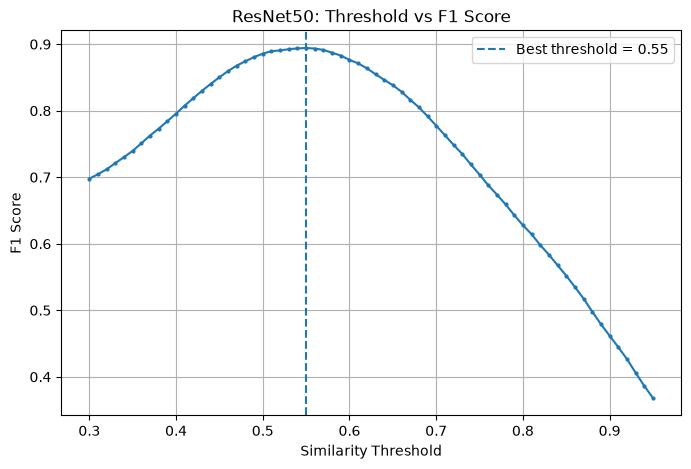

In [28]:
import matplotlib.pyplot as plt

threshold_values = np.arange(0.30, 0.96, 0.01)
f1_values = []

for threshold in threshold_values:

    y_pred = [
        1 if score >= threshold else 0
        for score in scores
    ]

    f1_values.append(
        f1_score(y_true, y_pred)
    )

plt.figure(figsize=(8, 5))

plt.plot(
    threshold_values,
    f1_values,
    marker="o",
    markersize=2
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best threshold = {best_threshold:.2f}"
)

plt.xlabel("Similarity Threshold")
plt.ylabel("F1 Score")
plt.title("ResNet50: Threshold vs F1 Score")
plt.legend()
plt.grid()
plt.show()

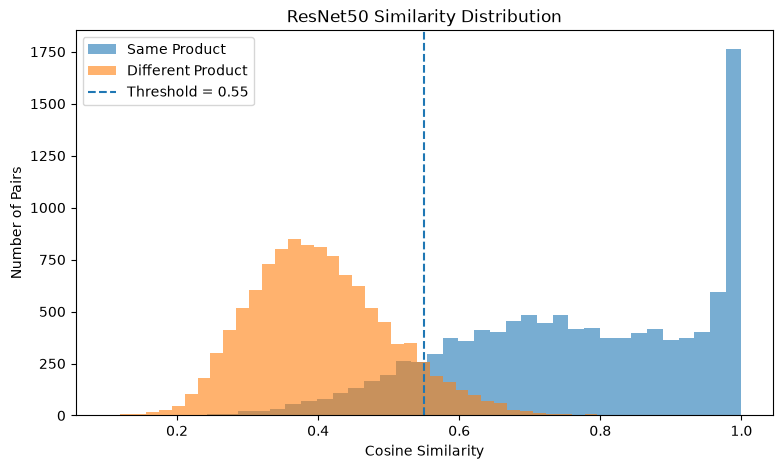

In [29]:
positive_scores = np.array(
    scores[:len(positive_pairs)]
)

negative_scores = np.array(
    scores[len(positive_pairs):]
)

plt.figure(figsize=(9, 5))

plt.hist(
    positive_scores,
    bins=40,
    alpha=0.6,
    label="Same Product"
)

plt.hist(
    negative_scores,
    bins=40,
    alpha=0.6,
    label="Different Product"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Threshold = {best_threshold:.2f}"
)

plt.xlabel("Cosine Similarity")
plt.ylabel("Number of Pairs")
plt.title("ResNet50 Similarity Distribution")
plt.legend()
plt.show()

#### Experiment 2

In [30]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

In [31]:
efficient_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)

print("EfficientNet-B0 loaded.")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
EfficientNet-B0 loaded.


In [32]:
def efficient_load_and_preprocess(path):

    img = tf.io.read_file(path)

    img = tf.image.decode_jpeg(
        img,
        channels=3
    )

    img = tf.image.resize(
        img,
        (224, 224)
    )

    img = efficientnet_preprocess(img)

    return img

In [33]:
efficient_dataset = tf.data.Dataset.from_tensor_slices(
    image_paths
)

efficient_dataset = efficient_dataset.map(
    efficient_load_and_preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)

efficient_dataset = efficient_dataset.batch(64)

efficient_dataset = efficient_dataset.prefetch(
    tf.data.AUTOTUNE
)

In [34]:
efficient_embeddings = efficient_model.predict(
    efficient_dataset
)

536/536 ━━━━━━━━━━━━━━━━━━━━ 512s 950ms/step


In [35]:
print(efficient_embeddings.shape)

(34250, 1280)


In [36]:
efficient_embeddings = (
    efficient_embeddings /
    np.linalg.norm(
        efficient_embeddings,
        axis=1,
        keepdims=True
    )
)

print(efficient_embeddings.shape)

(34250, 1280)


In [37]:
efficient_scores = []

for a, b in positive_pairs:

    score = np.dot(
        efficient_embeddings[a],
        efficient_embeddings[b]
    )

    efficient_scores.append(score)


for a, b in negative_pairs:

    score = np.dot(
        efficient_embeddings[a],
        efficient_embeddings[b]
    )

    efficient_scores.append(score)

In [38]:
efficient_best_threshold = None
efficient_best_f1 = 0

for threshold in np.arange(0.30, 0.96, 0.01):

    y_pred = [
        1 if score >= threshold else 0
        for score in efficient_scores
    ]

    f1 = f1_score(
        y_true,
        y_pred
    )

    if f1 > efficient_best_f1:

        efficient_best_f1 = f1
        efficient_best_threshold = threshold

print(
    "EfficientNet best threshold:",
    efficient_best_threshold
)

print(
    "EfficientNet best F1:",
    efficient_best_f1
)

EfficientNet best threshold: 0.34
EfficientNet best F1: 0.927591881513988


In [39]:
efficient_y_pred = [
    1 if score >= efficient_best_threshold else 0
    for score in efficient_scores
]

efficient_precision = precision_score(
    y_true,
    efficient_y_pred
)

efficient_recall = recall_score(
    y_true,
    efficient_y_pred
)

efficient_f1 = f1_score(
    y_true,
    efficient_y_pred
)

print("Precision:", efficient_precision)
print("Recall:", efficient_recall)
print("F1:", efficient_f1)

Precision: 0.9340821211563248
Recall: 0.9211912111857635
F1: 0.927591881513988


In [40]:
results = pd.DataFrame({
    "Experiment": [
        "Baseline",
        "Experiment 1"
    ],
    
    "Model": [
        "ResNet50",
        "EfficientNet-B0"
    ],
    
    "Embedding Dimension": [
        2048,
        1280
    ],
    
    "Similarity": [
        "Cosine",
        "Cosine"
    ],
    
    "Threshold": [
        best_threshold,
        efficient_best_threshold
    ],
    
    "Precision": [
        precision_score(y_true, y_pred),
        efficient_precision
    ],
    
    "Recall": [
        recall_score(y_true, y_pred),
        efficient_recall
    ],
    
    "F1": [
        best_f1,
        efficient_f1
    ]
})

results

,Experiment,Model,Embedding Dimension,Similarity,Threshold,Precision,Recall,F1
0,Baseline,ResNet50,2048,Cosine,0.55,1.000000,0.212729,0.894249
1,Experiment 1,EfficientNet-B0,1280,Cosine,0.34,0.934082,0.921191,0.927592


In [41]:
results.to_csv(
    r"D:\weq-preview\madatory task 1\image_matching_results.csv",
    index=False
)

print("Results saved.")

Results saved.


In [42]:
query_idx = 0

In [43]:
query_embedding = embeddings[query_idx]

similarities = np.dot(
    embeddings,
    query_embedding
)

In [44]:
top_indices = np.argsort(
    similarities
)[::-1][:6]

top_scores = similarities[top_indices]

print("Query:", data.iloc[query_idx]["image"])

for idx, score in zip(top_indices, top_scores):

    print(
        idx,
        data.iloc[idx]["image"],
        "Score:",
        round(score, 4),
        "Group:",
        data.iloc[idx]["label_group"]
    )

Query: 0000a68812bc7e98c42888dfb1c07da0.jpg
0 0000a68812bc7e98c42888dfb1c07da0.jpg Score: 1.0 Group: 249114794
19243 90ff48781dfc4a683314b599be8b7f23.jpg Score: 0.8421 Group: 2344108647
29316 db9c6459d126b666ecf93972f878e4e6.jpg Score: 0.8068 Group: 2344108647
16409 7b9dd41319f8e37fe63ba7f8f6dac17a.jpg Score: 0.6539 Group: 994676122
33231 f8b1745422209fef3b4c785eb35973a1.jpg Score: 0.644 Group: 788608170
22686 aa57649f932b6814ecdd2f10b4d85e13.jpg Score: 0.6425 Group: 994676122


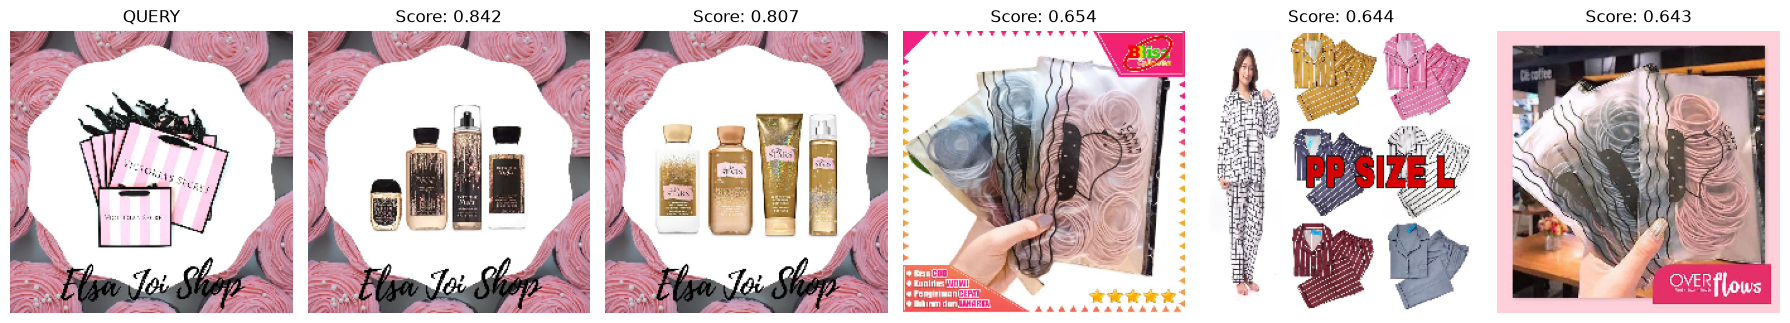

In [45]:
fig, axes = plt.subplots(
    1,
    6,
    figsize=(18, 4)
)

for i, (idx, score) in enumerate(
    zip(top_indices, top_scores)
):

    img = load_img(
        image_paths[idx],
        target_size=(224, 224)
    )

    axes[i].imshow(img)

    if i == 0:
        title = "QUERY"
    else:
        title = f"Score: {score:.3f}"

    axes[i].set_title(title)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [46]:
query_group = data.iloc[
    query_idx
]["label_group"]

print("Query group:", query_group)

for idx in top_indices[1:]:

    neighbor_group = data.iloc[
        idx
    ]["label_group"]

    print(
        data.iloc[idx]["image"],
        "→",
        "SAME PRODUCT"
        if neighbor_group == query_group
        else "DIFFERENT PRODUCT"
    )

Query group: 249114794
90ff48781dfc4a683314b599be8b7f23.jpg → DIFFERENT PRODUCT
db9c6459d126b666ecf93972f878e4e6.jpg → DIFFERENT PRODUCT
7b9dd41319f8e37fe63ba7f8f6dac17a.jpg → DIFFERENT PRODUCT
f8b1745422209fef3b4c785eb35973a1.jpg → DIFFERENT PRODUCT
aa57649f932b6814ecdd2f10b4d85e13.jpg → DIFFERENT PRODUCT


In [47]:
false_positives = []

for (a, b), score in zip(
    negative_pairs,
    scores[len(positive_pairs):]
):

    if score >= best_threshold:

        false_positives.append(
            (a, b, score)
        )

print(
    "False positives:",
    len(false_positives)
)

False positives: 906


In [48]:
false_negatives = []

for (a, b), score in zip(
    positive_pairs,
    scores[:len(positive_pairs)]
):

    if score < best_threshold:

        false_negatives.append(
            (a, b, score)
        )

print(
    "False negatives:",
    len(false_negatives)
)

False negatives: 1374


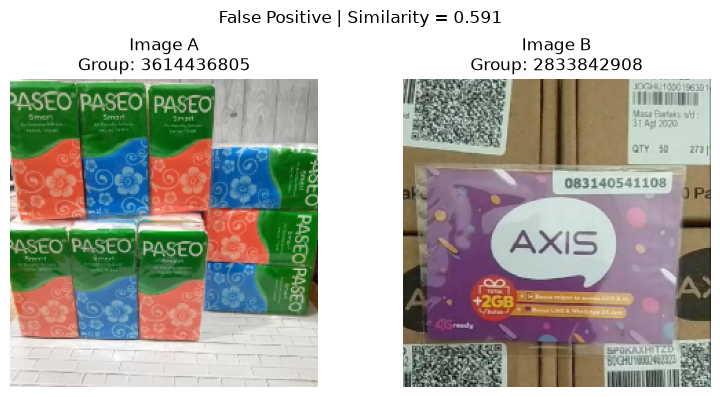

In [49]:
a, b, score = false_positives[0]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(8, 4)
)

axes[0].imshow(
    load_img(
        image_paths[a],
        target_size=(224, 224)
    )
)

axes[0].set_title(
    f"Image A\nGroup: {labels[a]}"
)

axes[1].imshow(
    load_img(
        image_paths[b],
        target_size=(224, 224)
    )
)

axes[1].set_title(
    f"Image B\nGroup: {labels[b]}"
)

for ax in axes:
    ax.axis("off")

plt.suptitle(
    f"False Positive | Similarity = {score:.3f}"
)

plt.tight_layout()
plt.show()

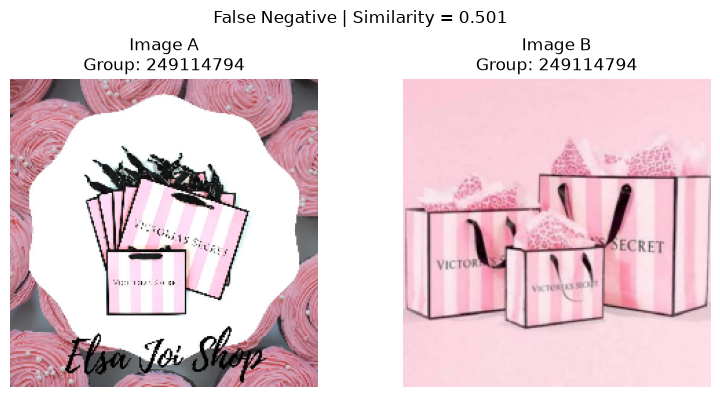

In [50]:
a, b, score = false_negatives[0]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(8, 4)
)

axes[0].imshow(
    load_img(
        image_paths[a],
        target_size=(224, 224)
    )
)

axes[0].set_title(
    f"Image A\nGroup: {labels[a]}"
)

axes[1].imshow(
    load_img(
        image_paths[b],
        target_size=(224, 224)
    )
)

axes[1].set_title(
    f"Image B\nGroup: {labels[b]}"
)

for ax in axes:
    ax.axis("off")

plt.suptitle(
    f"False Negative | Similarity = {score:.3f}"
)

plt.tight_layout()
plt.show()

In [51]:
neighbor_results = []

for idx, score in zip(
    top_indices,
    top_scores
):

    neighbor_results.append({
        "image": data.iloc[idx]["image"],
        "label_group": data.iloc[idx]["label_group"],
        "similarity": float(score)
    })

neighbor_df = pd.DataFrame(
    neighbor_results
)

neighbor_df

,image,label_group,similarity
0,0000a68812bc7e98c42888dfb1c07da0.jpg,249114794,1.000000
1,90ff48781dfc4a683314b599be8b7f23.jpg,2344108647,0.842141
2,db9c6459d126b666ecf93972f878e4e6.jpg,2344108647,0.806768
3,7b9dd41319f8e37fe63ba7f8f6dac17a.jpg,994676122,0.653894
4,f8b1745422209fef3b4c785eb35973a1.jpg,788608170,0.644021
5,aa57649f932b6814ecdd2f10b4d85e13.jpg,994676122,0.642540


## Computational Considerations

The dataset contains 34,250 training images. Each image is
passed through a pretrained CNN to obtain an image embedding.

For the ResNet50 experiment, each image is represented by a
2048-dimensional embedding. EfficientNet-B0 produces a
1280-dimensional embedding.

Embedding extraction is computationally expensive because
the CNN must process every image. Therefore, the embeddings
are saved and reused for later similarity experiments.

Comparing every possible pair of 34,250 images would require
approximately 587 million pairwise comparisons. Therefore,
sampling is used for matching evaluation, while nearest
neighbor search can be performed using vectorized similarity
search. For larger datasets, approximate nearest-neighbor
libraries such as FAISS could be considered.

## Conclusion

This experiment investigated image-based product matching
using pretrained visual representations.

ResNet50 was used as the baseline model to convert product
images into 2048-dimensional embeddings. Cosine similarity
was then used to measure visual similarity between product
images. A matching threshold was selected using F1-score on
positive and negative product pairs.

EfficientNet-B0 was evaluated as a second visual
representation and compared with the ResNet50 baseline.

Nearest-neighbor analysis was used to determine whether
visually similar images actually belonged to the same
product group.

Error analysis showed that visual matching can be affected
by differences in viewpoint, background, packaging, color,
cropping, image quality, and visually similar but distinct
products.

Overall, pretrained image embeddings provide a useful way
to perform visual product matching without training a
computer vision model from scratch.